<a href="https://colab.research.google.com/github/Akshayus29/Assignments/blob/main/casestudy_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.naive_bayes import GaussianNB #NB
from sklearn.tree import DecisionTreeClassifier #DT
from sklearn.svm import SVC #SVM
from sklearn.model_selection import GridSearchCV #model fine tuning
from sklearn.ensemble import RandomForestClassifier  # Model Feature Selection

### Load Data(Training Data)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

filepath='/content/drive/MyDrive/DSA folder/Data/Training_data.csv'
trn=pd.read_csv(filepath)
trn.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


### **Data Cleaning**

In [3]:
trn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


Handling Duplicates

In [4]:
trn.duplicated().sum()

np.int64(0)

Handling Missing Values

In [6]:
trn.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


<Axes: >

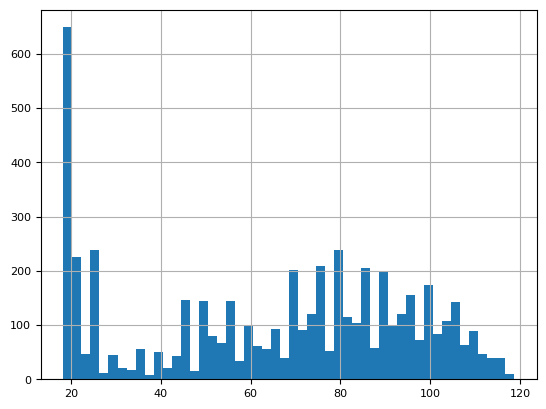

In [7]:
trn['MonthlyCharges'].hist(bins=50,xlabelsize=8,ylabelsize=8)

<Axes: >

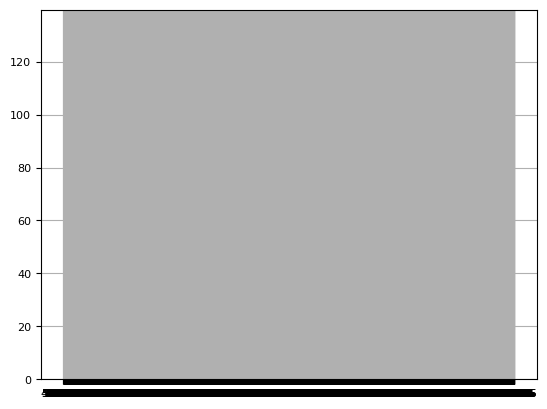

In [8]:
trn['TotalCharges'].hist(bins=50,xlabelsize=8,ylabelsize=8)

In [9]:
trn['TotalCharges'].dtype

dtype('O')

In [11]:
trn = trn.dropna(subset=['gender'])
trn['OnlineSecurity'] = trn['OnlineSecurity'].fillna(trn['OnlineSecurity'].mode()[0])

In [12]:
trn['MonthlyCharges'] = trn['MonthlyCharges'].fillna(trn['MonthlyCharges'].median())

In [13]:
trn['TotalCharges'] = pd.to_numeric(trn['TotalCharges'], errors='coerce')
trn['TotalCharges'].isnull().sum()

np.int64(283)

In [14]:
trn['TotalCharges'] = trn['TotalCharges'].fillna(trn['TotalCharges'].median())

In [15]:
trn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Handling Outliers

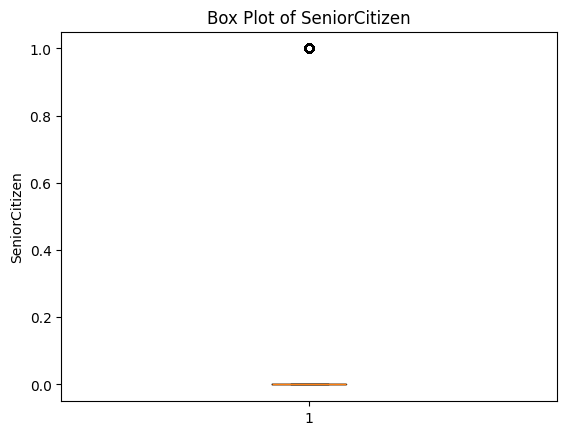

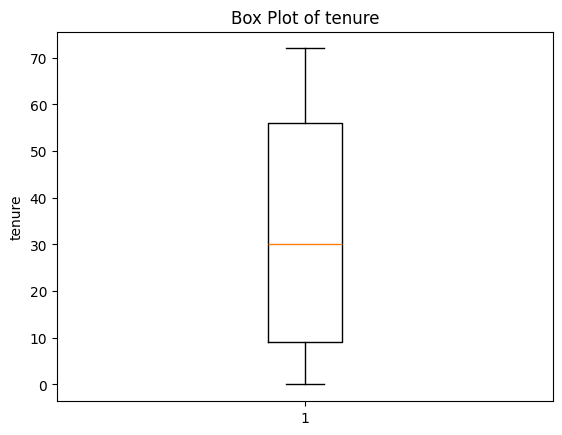

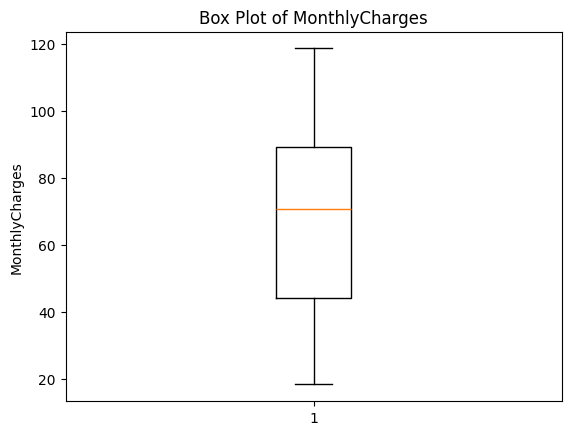

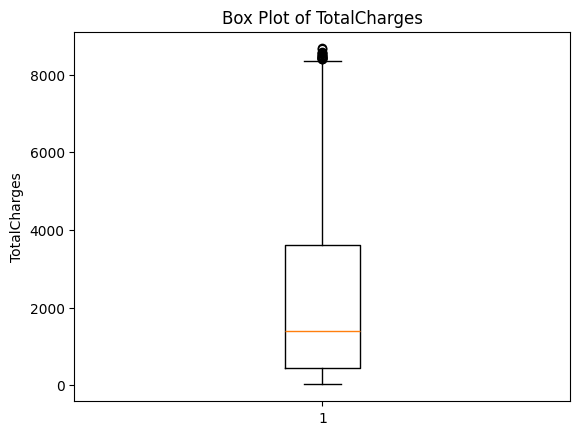

In [16]:
num_cols = trn.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(trn[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

<Axes: >

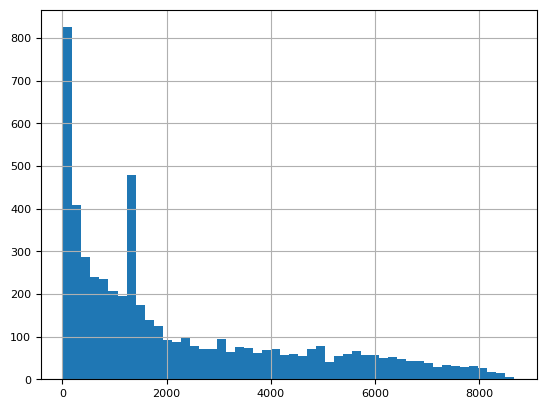

In [17]:
trn['TotalCharges'].hist(bins=50,xlabelsize=8,ylabelsize=8)

Outlier Removal(IQR Method)

In [18]:
q1=np.percentile(trn['TotalCharges'],25)
q3=np.percentile(trn['TotalCharges'],75)
iqr=q3-q1
print(q1,q3,iqr)


449.3 3617.1 3167.7999999999997


In [19]:
up_val=q3+1.5*iqr
low_val=q1-1.5*iqr
print(up_val,low_val)

8368.8 -4302.4


<Axes: >

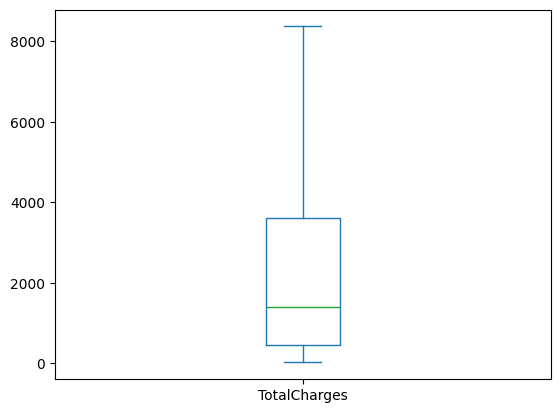

In [20]:
trn['TotalCharges']=trn['TotalCharges'].clip(lower=low_val,upper=up_val)
trn['TotalCharges'].plot(kind='box')

### **Feature Engineering**

In [21]:
trn1=trn.select_dtypes(include=['number'])
corr=trn1.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.021622,0.205371,0.102725
tenure,0.021622,1.000000,0.231534,0.797000
MonthlyCharges,0.205371,0.231534,1.000000,0.606818
TotalCharges,0.102725,0.797000,0.606818,1.000000


<Axes: >

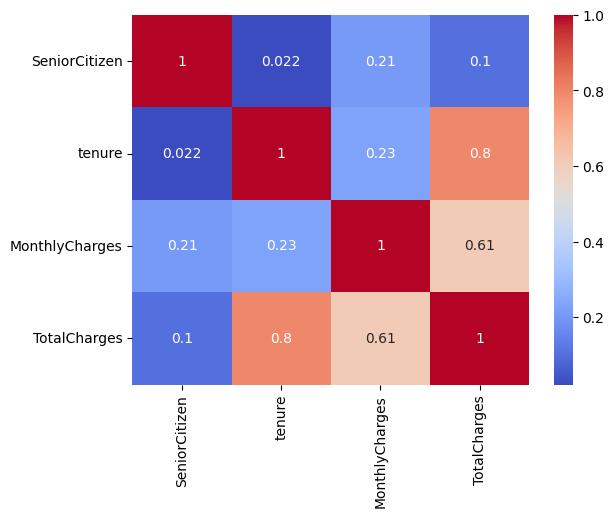

In [22]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

Adding new features to dataset:

Customer Lifetime Value (CLV)

In [23]:
trn['CLV'] = trn['tenure'] * trn['MonthlyCharges']

In [24]:
trn['AvgMonthlySpend'] = trn['TotalCharges'] / (trn['tenure'] + 1)

Tenure Group

In [25]:
trn['TenureGroup'] = pd.cut(
    trn['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)

Tenure-Contract Interaction

In [26]:
contract_weight = {
    'Month-to-month': 1,
    'One year': 12,
    'Two year': 24
}
trn['ContractWeight'] = trn['Contract'].map(contract_weight)
trn['Tenure_Contract'] = trn['tenure'] * trn['ContractWeight']

In [27]:
trn[['CLV', 'AvgMonthlySpend', 'TenureGroup','Tenure_Contract']].head()

,CLV,AvgMonthlySpend,TenureGroup,Tenure_Contract
0,726.25,19.456944,2-4yr,420
1,1001.00,33.151724,2-4yr,28
2,5521.60,97.913158,4-6yr,56
3,797.55,19.750000,2-4yr,936
4,2203.75,48.900000,2-4yr,516


### **Encoding**

In [28]:
for col in trn.columns:
    print(f"\nColumn: {col}")
    print(trn[col].value_counts(dropna=False))



Column: customerID
customerID
9110-HSGTV    1
9509-MPYOD    1
7746-AWNQW    1
2208-UGTGR    1
4884-LEVMQ    1
             ..
3108-PCCGG    1
8309-PPCED    1
6941-KXRRV    1
5195-KPUNQ    1
4826-TZEVA    1
Name: count, Length: 5465, dtype: int64

Column: gender
gender
Male      2744
Female    2721
Name: count, dtype: int64

Column: SeniorCitizen
SeniorCitizen
0    4588
1     877
Name: count, dtype: int64

Column: Partner
Partner
No     2805
Yes    2660
Name: count, dtype: int64

Column: Dependents
Dependents
No     3845
Yes    1620
Name: count, dtype: int64

Column: tenure
tenure
1     466
72    296
2     182
3     149
4     137
     ... 
38     44
36     43
39     42
44     41
0       8
Name: count, Length: 73, dtype: int64

Column: PhoneService
PhoneService
Yes    4936
No      529
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  2616
Yes                 2320
No phone service     529
Name: count, dtype: int64

Column: InternetService
InternetService


In [29]:
trn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5465 entries, 0 to 5632
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        5465 non-null   object  
 1   gender            5465 non-null   object  
 2   SeniorCitizen     5465 non-null   int64   
 3   Partner           5465 non-null   object  
 4   Dependents        5465 non-null   object  
 5   tenure            5465 non-null   int64   
 6   PhoneService      5465 non-null   object  
 7   MultipleLines     5465 non-null   object  
 8   InternetService   5465 non-null   object  
 9   OnlineSecurity    5465 non-null   object  
 10  OnlineBackup      5465 non-null   object  
 11  DeviceProtection  5465 non-null   object  
 12  TechSupport       5465 non-null   object  
 13  StreamingTV       5465 non-null   object  
 14  StreamingMovies   5465 non-null   object  
 15  Contract          5465 non-null   object  
 16  PaperlessBilling  5465 non-nu

Binary Encoding

In [30]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
    trn[col] = trn[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})


One Hot Encoding

In [51]:
onehot_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Contract','PaymentMethod','TenureGroup']

trn = pd.get_dummies(trn, columns = onehot_cols, drop_first=True,dtype=int)

# Drop original columns that were one-hot encoded
trn = trn.drop(columns=[col for col in onehot_cols if col in trn.columns])

### **Scaling**

Min max scaling

In [34]:
scale_cols= ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges',
             'CLV','AvgMonthlySpend','ContractWeight','Tenure_Contract']

# scaler = StandardScaler()
# trn[scale_cols] = scaler.fit_transform(trn[scale_cols])

scaler = MinMaxScaler()
trn[scale_cols] = scaler.fit_transform(trn[scale_cols])


In [35]:
trn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV,AvgMonthlySpend,TenureGroup,ContractWeight,Tenure_Contract
0,9509-MPYOD,0,0.0,0,0,0.486111,1,No,No,No internet service,...,0,Mailed check,0.024876,0.081629,0,0.084942,0.007383,2-4yr,0.478261,0.243056
1,7746-AWNQW,0,0.0,0,0,0.388889,0,No phone service,DSL,No,...,1,Mailed check,0.174129,0.112881,0,0.117076,0.017224,2-4yr,0.000000,0.016204
2,2208-UGTGR,1,0.0,0,0,0.777778,1,Yes,Fiber optic,No,...,0,Electronic check,0.799502,0.666136,0,0.645801,0.063764,4-6yr,0.000000,0.032407
3,4884-LEVMQ,1,0.0,1,0,0.541667,1,No,No,No internet service,...,1,Bank transfer (automatic),0.021891,0.092354,0,0.093281,0.007593,2-4yr,1.000000,0.541667
4,6682-VCIXC,0,0.0,1,1,0.597222,0,No phone service,DSL,No,...,1,Bank transfer (automatic),0.328358,0.255421,0,0.257749,0.028541,2-4yr,0.478261,0.298611


### **Train-Test Split**

In [52]:
X = trn.drop(['Churn', 'customerID'], axis=1)
y = trn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=55)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4372, 37)
(1093, 37)
(4372,)
(1093,)


### **ML Modeling Using Classification Methods**

1.Logistic Regression

In [54]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [55]:
y_pred_lr=lr.predict(X_test)

In [56]:
print(f'accuracy_score= {accuracy_score(y_test,y_pred_lr)}')
print(f'precision= {precision_score(y_test,y_pred_lr)}')
print(f'f1= {f1_score(y_test,y_pred_lr)}')
print(f'recall= {recall_score(y_test,y_pred_lr)}')
print(f'conf_matrix= {confusion_matrix(y_test,y_pred_lr)}')
print(f'classification_report= {classification_report(y_test,y_pred_lr)}')

accuracy_score= 0.8014638609332113
precision= 0.6622222222222223
f1= 0.5786407766990291
recall= 0.5137931034482759
conf_matrix= [[727  76]
 [141 149]]
classification_report=               precision    recall  f1-score   support

           0       0.84      0.91      0.87       803
           1       0.66      0.51      0.58       290

    accuracy                           0.80      1093
   macro avg       0.75      0.71      0.72      1093
weighted avg       0.79      0.80      0.79      1093



2.KNN

Using Euclidian

In [57]:
#we need to figure out the optimum value for k.
#to do that, we will check which value of k is giving highest accuracy.

accuracy_list = []
neighbors_range = np.arange(1,30)

for k in neighbors_range:
  classifier = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=2)  # initialising classifier for iteration using Euclidian p=2
  #Training the ML model
  classifier.fit(X_train, y_train)
  y_pred_eu=classifier.predict(X_test)  #predict using trained ML model
  acc = accuracy_score(y_test,y_pred_eu)  # evaluate the ML model
  accuracy_list.append(acc) #appending acc list with accuracy achieved for each value of k

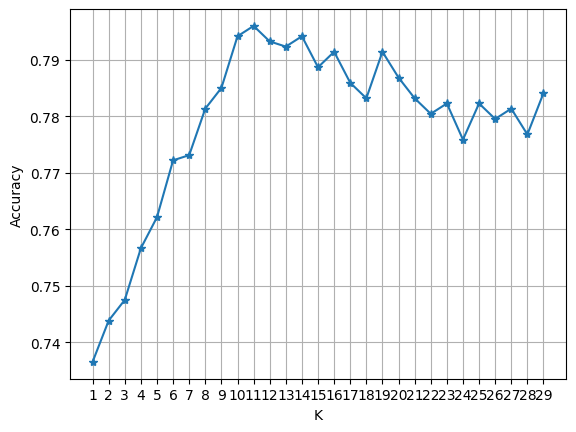

In [58]:
plt.plot(neighbors_range, accuracy_list,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()

Taking Value of k=25

In [59]:
classifier_knn = KNeighborsClassifier(n_neighbors=25, metric='euclidean')
classifier_knn.fit(X_train,y_train)
y_pred_knn_eu = classifier_knn.predict(X_test)
acc_knn=accuracy_score(y_test,y_pred_knn_eu)
prec_knn=precision_score(y_test,y_pred_knn_eu)
rec_knn=recall_score(y_test,y_pred_knn_eu)
f1_knn=f1_score(y_test,y_pred_knn_eu)


In [60]:
print('Accuracy:',acc_knn)
print('Precision:',prec_knn)
print('Recall:',rec_knn)
print('F1 Score:',f1_knn)
confusion_matrix(y_test,y_pred_knn_eu)

Accuracy: 0.7822506861848124
Precision: 0.5955882352941176
Recall: 0.5586206896551724
F1 Score: 0.5765124555160143


array([[693, 110],
       [128, 162]])

Using Manhattan

In [61]:
accuracy_list1 = []
neighbors_range1 = np.arange(1,30)

for k in neighbors_range:
  classifier1 = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=1)  # initialising classifier for iteration using manhattan p=1
  #Training the ML model
  classifier1.fit(X_train, y_train)
  y_pred_mn=classifier1.predict(X_test)  #predict using trained ML model
  acc1 = accuracy_score(y_test,y_pred_mn)  # evaluate the ML model
  accuracy_list1.append(acc1) #appending acc list with accuracy achieved for each value of k

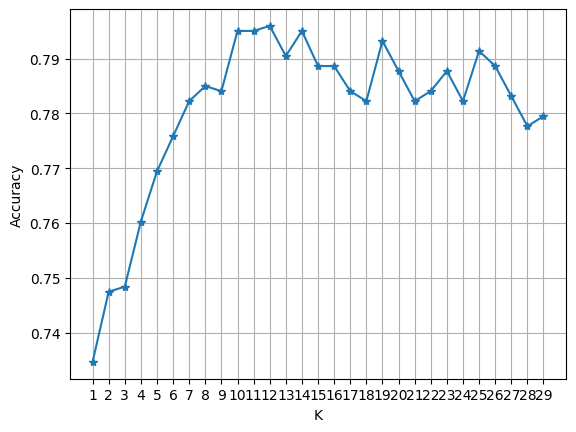

In [62]:
plt.plot(neighbors_range1, accuracy_list1,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range1)
plt.grid()

In [63]:
classifier1_knn = KNeighborsClassifier(n_neighbors=28, metric='manhattan') #using K=28
classifier1_knn.fit(X_train,y_train)
y_pred_knn_mn = classifier1_knn.predict(X_test)
acc_knn1=accuracy_score(y_test,y_pred_knn_mn)
prec_knn1=precision_score(y_test,y_pred_knn_mn)
rec_knn1=recall_score(y_test,y_pred_knn_mn)
f1_knn1=f1_score(y_test,y_pred_knn_mn)

In [64]:
print('Accuracy:',acc_knn1)
print('Precision:',prec_knn1)
print('Recall:',rec_knn1)
print('F1 Score:',f1_knn1)
confusion_matrix(y_test,y_pred_knn_mn)

Accuracy: 0.777676120768527
Precision: 0.5893536121673004
Recall: 0.5344827586206896
F1 Score: 0.5605786618444847


array([[695, 108],
       [135, 155]])

3.Naive Baye's

In [65]:
#initializing the model
nb=GaussianNB()
#training the model
nb.fit(X_train,y_train)
#predict using trained ML model
y_pred_nb=nb.predict(X_test)
#evaluate the model
acc_nb=accuracy_score(y_test,y_pred_nb)
prec_nb=precision_score(y_test,y_pred_nb)
rec_nb=recall_score(y_test,y_pred_nb)
f1_nb=f1_score(y_test,y_pred_nb)

In [66]:
print('Accuracy:',acc_nb)
print('Precision:',prec_nb)
print('Recall:',rec_nb)
print('F1 Score:',f1_nb)
confusion_matrix(y_test,y_pred_nb)

Accuracy: 0.7008234217749314
Precision: 0.4655493482309125
Recall: 0.8620689655172413
F1 Score: 0.6045949214026602


array([[516, 287],
       [ 40, 250]])

4.Decision Tree

In [67]:
#initializing the model
dt=DecisionTreeClassifier()
#training the model
dt.fit(X_train,y_train)
#predict using trained ML model
y_pred_dt=dt.predict(X_test)
#evaluate the model
acc_dt=accuracy_score(y_test,y_pred_dt)
prec_dt= precision_score(y_test,y_pred_dt)
rec_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)

In [68]:
print('Accuracy:',acc_dt)
print('Precision:',prec_dt)
print('Recall:',rec_dt)
print('F1 Score:',f1_dt)
confusion_matrix(y_test,y_pred_dt)

Accuracy: 0.7291857273559011
Precision: 0.4894366197183099
Recall: 0.4793103448275862
F1 Score: 0.4843205574912892


array([[658, 145],
       [151, 139]])

5.SVM (SVC)

In [69]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=55)  ##initializing the model
svm_clf.fit(X_train, y_train)   ##training the model
y_pred_sv = svm_clf.predict(X_test)  ##training the model

In [70]:
#evaluating the model
acc_sv=accuracy_score(y_test,y_pred_sv)
prec_sv= precision_score(y_test,y_pred_sv)
rec_sv=recall_score(y_test,y_pred_sv)
f1_sv=f1_score(y_test,y_pred_sv)


print('Accuracy:',acc_sv)
print('Precision:',prec_sv)
print('Recall:',rec_sv)
print('F1 Score:',f1_sv)
confusion_matrix(y_test,y_pred_sv)

Accuracy: 0.7959743824336688
Precision: 0.6650246305418719
Recall: 0.46551724137931033
F1 Score: 0.5476673427991886


array([[735,  68],
       [155, 135]])

### **Logistic Regression Model Fine Tuning using Grid Search CV**

In [71]:
lr1 = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(lr1, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_


In [72]:
y_pred_lr1 = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print("Best Params:", grid_lr.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_lr1))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8023787740164684
ROC-AUC: 0.8575814832309872


### **Model feature Selection**

Reducing features; Selecting most important 20 features for modeling .

Tree-Based Feature Importance Method

In [73]:
rf = RandomForestClassifier(n_estimators=200,random_state=55)
rf.fit(X, y)

# Feature importance ranking
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(20)

,Feature,Importance
12,Tenure_Contract,0.117558
9,CLV,0.109205
7,MonthlyCharges,0.102573
10,AvgMonthlySpend,0.100433
8,TotalCharges,0.099669
4,tenure,0.081430
11,ContractWeight,0.043882
15,InternetService_Fiber optic,0.038157
32,PaymentMethod_Electronic check,0.023840
0,gender,0.019443


In [74]:
top_features = feature_importance['Feature'].head(20).tolist()

X_train_reduced= X_train[top_features]
X_test_reduced = X_test[top_features]

Performing Logistic Regression, KNN, DT, NV & SVM using reduced feature dataset

1.Logistic Regression

In [75]:
lr1_red=LogisticRegression()
lr1_red.fit(X_train_reduced,y_train)

y_pred_lr_red=lr1_red.predict(X_test_reduced)

print(f'accuracy_score= {accuracy_score(y_test,y_pred_lr_red)}')
print(f'precision= {precision_score(y_test,y_pred_lr_red)}')
print(f'f1= {f1_score(y_test,y_pred_lr_red)}')
print(f'recall= {recall_score(y_test,y_pred_lr_red)}')
print(f'conf_matrix= {confusion_matrix(y_test,y_pred_lr_red)}')

accuracy_score= 0.8042086001829826
precision= 0.6666666666666666
f1= 0.5868725868725869
recall= 0.5241379310344828
conf_matrix= [[727  76]
 [138 152]]


In [76]:
# using fine tuned model
lr_reduced = LogisticRegression(C=10,penalty='l1',solver='liblinear',max_iter=1000)

lr_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = lr_reduced.predict(X_test_reduced)
y_prob_reduced = lr_reduced.predict_proba(X_test_reduced)[:, 1]

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred_reduced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_reduced))

Accuracy: 0.8042086001829826
ROC-AUC: 0.8566453386009361


2.KNN

Using Euclidian

In [78]:
#we need to figure out the optimum value for k.
#to do that, we will check which value of k is giving highest accuracy.

accuracy_list3 = []
neighbors_range3 = np.arange(1,30)

for k in neighbors_range3:
  classifier3 = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=2)  # initialising classifier for iteration using Euclidian p=2
  #Training the ML model
  classifier3.fit(X_train_reduced, y_train)
  y_pred_eu_red=classifier3.predict(X_test_reduced)  #predict using trained ML model
  acc3 = accuracy_score(y_test,y_pred_eu_red)  # evaluate the ML model
  accuracy_list3.append(acc3) #appending acc list with accuracy achieved for each value of k

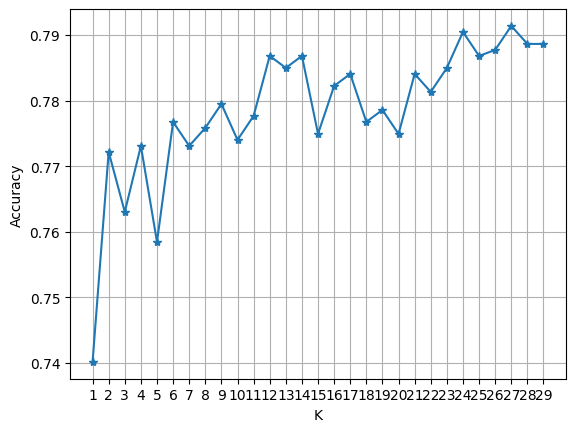

In [79]:
plt.plot(neighbors_range3, accuracy_list3,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range3)
plt.grid()

Taking Value of k=29

In [80]:
classifier_knn3 = KNeighborsClassifier(n_neighbors=29, metric='euclidean')  #usking k=29
classifier_knn3.fit(X_train_reduced,y_train)
y_pred_knn_eu_red = classifier_knn3.predict(X_test_reduced)
acc_knn3=accuracy_score(y_test,y_pred_knn_eu_red)
prec_knn3=precision_score(y_test,y_pred_knn_eu_red)
rec_knn3=recall_score(y_test,y_pred_knn_eu_red)
f1_knn3=f1_score(y_test,y_pred_knn_eu_red)


In [81]:
print('Accuracy:',acc_knn3)
print('Precision:',prec_knn3)
print('Recall:',rec_knn3)
print('F1 Score:',f1_knn3)
confusion_matrix(y_test,y_pred_knn_eu_red)

Accuracy: 0.7886550777676121
Precision: 0.6244725738396625
Recall: 0.5103448275862069
F1 Score: 0.5616698292220114


array([[714,  89],
       [142, 148]])

Using Manhattan

In [82]:
accuracy_list4 = []
neighbors_range4 = np.arange(1,30)

for k in neighbors_range4:
  classifier4 = KNeighborsClassifier(n_neighbors=k , metric='minkowski',p=1)  # initialising classifier for iteration using manhattan p=1
  #Training the ML model
  classifier4.fit(X_train_reduced, y_train)
  y_pred_mn_red=classifier4.predict(X_test_reduced)  #predict using trained ML model
  acc4 = accuracy_score(y_test,y_pred_mn_red)  # evaluate the ML model
  accuracy_list4.append(acc4) #appending acc list with accuracy achieved for each value of k

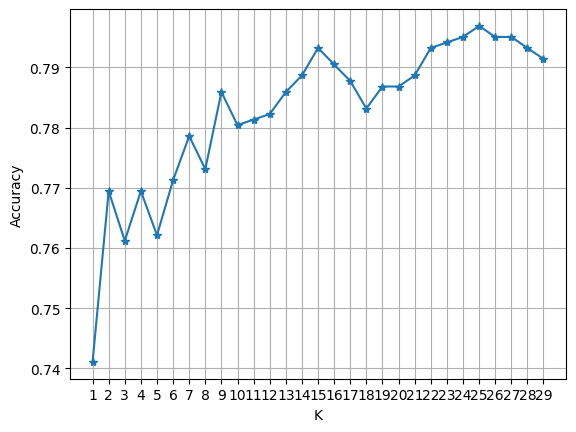

In [83]:
plt.plot(neighbors_range4, accuracy_list4,'*-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range4)
plt.grid()

In [84]:
classifier4_knn = KNeighborsClassifier(n_neighbors=27, metric='manhattan') #using k=27
classifier4_knn.fit(X_train_reduced,y_train)
y_pred_knn_mn_red = classifier4_knn.predict(X_test_reduced)
acc_knn4=accuracy_score(y_test,y_pred_knn_mn_red)
prec_knn4=precision_score(y_test,y_pred_knn_mn_red)
rec_knn4=recall_score(y_test,y_pred_knn_mn_red)
f1_knn4=f1_score(y_test,y_pred_knn_mn_red)

In [85]:
print('Accuracy:',acc_knn4)
print('Precision:',prec_knn4)
print('Recall:',rec_knn4)
print('F1 Score:',f1_knn4)
confusion_matrix(y_test,y_pred_knn_mn_red)

Accuracy: 0.7950594693504117
Precision: 0.6341463414634146
Recall: 0.5379310344827586
F1 Score: 0.582089552238806


array([[713,  90],
       [134, 156]])

3.Naive Baye's

In [86]:
#initializing the model
dt2=DecisionTreeClassifier()
#training the model
dt2.fit(X_train_reduced,y_train)
#predict using trained ML model
y_pred_dt_red=dt2.predict(X_test_reduced)
#evaluate the model
acc_dt2=accuracy_score(y_test,y_pred_dt_red)
prec_dt2= precision_score(y_test,y_pred_dt_red)
rec_dt2=recall_score(y_test,y_pred_dt_red)
f1_dt2=f1_score(y_test,y_pred_dt_red)

In [87]:
print('Accuracy:',acc_dt2)
print('Precision:',prec_dt2)
print('Recall:',rec_dt2)
print('F1 Score:',f1_dt2)
confusion_matrix(y_test,y_pred_dt_red)

Accuracy: 0.7383348581884721
Precision: 0.506993006993007
Recall: 0.5
F1 Score: 0.5034722222222222


array([[662, 141],
       [145, 145]])

4.Decision Tree

In [88]:
#initializing the model
dt2=DecisionTreeClassifier()
#training the model
dt2.fit(X_train_reduced,y_train)
#predict using trained ML model
y_pred_dt_red=dt2.predict(X_test_reduced)
#evaluate the model
acc_dt2=accuracy_score(y_test,y_pred_dt_red)
prec_dt2= precision_score(y_test,y_pred_dt_red)
rec_dt2=recall_score(y_test,y_pred_dt_red)
f1_dt2=f1_score(y_test,y_pred_dt_red)

In [89]:
print('Accuracy:',acc_dt2)
print('Precision:',prec_dt2)
print('Recall:',rec_dt2)
print('F1 Score:',f1_dt2)
confusion_matrix(y_test,y_pred_dt_red)

Accuracy: 0.7264409881061299
Precision: 0.48514851485148514
Recall: 0.506896551724138
F1 Score: 0.4957841483979764


array([[647, 156],
       [143, 147]])

5.SVM (SVC)

In [90]:
svm_clf2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=55) ##initializing the model
svm_clf2.fit(X_train_reduced, y_train)  ##training the model
y_pred_sv_red = svm_clf2.predict(X_test_reduced)  ##predict using trained ML model

In [91]:
acc_sv2=accuracy_score(y_test,y_pred_sv_red)
prec_sv2= precision_score(y_test,y_pred_sv_red)
rec_sv2=recall_score(y_test,y_pred_sv_red)
f1_sv2=f1_score(y_test,y_pred_sv_red)


print('Accuracy:',acc_sv2)
print('Precision:',prec_sv2)
print('Recall:',rec_sv2)
print('F1 Score:',f1_sv2)
confusion_matrix(y_test,y_pred_sv_red)

Accuracy: 0.7932296431838975
Precision: 0.66
Recall: 0.45517241379310347
F1 Score: 0.5387755102040817


array([[735,  68],
       [158, 132]])

### **Choosing Logistic Regression modeling to perform on Testing Dataset as it gives highest accuracy.**

### **Load Data(Testing Data)**

In [92]:
from google.colab import drive
drive.mount('/content/drive')

filepath='/content/drive/MyDrive/DSA folder/Data/Testing_data.csv'
tes=pd.read_csv(filepath)
tes.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


### **Data Cleaning**

In [93]:
tes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [94]:
tes.drop(columns=['customerID','Churn'],inplace=True)

In [95]:
tes['TotalCharges'] = pd.to_numeric(tes['TotalCharges'], errors='coerce')

Handling Duplicates

In [96]:
tes.duplicated().sum()

np.int64(3)

In [97]:
tes[tes.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
307,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90
571,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90
1175,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05


In [98]:
tes = tes.drop_duplicates()

In [99]:
tes.duplicated().sum()

np.int64(0)

Handling Missing Values

In [100]:
tes.isnull().sum().sort_values(ascending=False)

,0
TotalCharges,2
SeniorCitizen,0
gender,0
Partner,0
Dependents,0
PhoneService,0
tenure,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [101]:
tes = tes.dropna(subset=['TotalCharges'])

In [102]:
tes.isnull().sum().sort_values(ascending=False)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


### **Feature Engineering**

In [103]:
tes1=tes.select_dtypes(include=['number'])
corr1=tes1.corr()
corr1

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,-0.008254,0.248067,0.085013
tenure,-0.008254,1.000000,0.275773,0.831058
MonthlyCharges,0.248067,0.275773,1.000000,0.661694
TotalCharges,0.085013,0.831058,0.661694,1.000000


<Axes: >

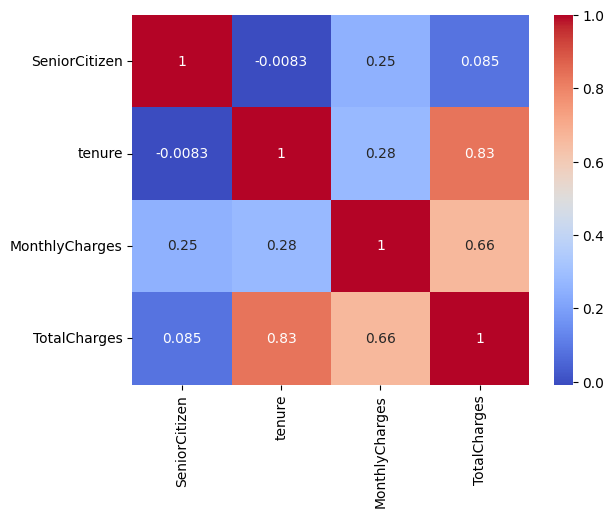

In [104]:
sns.heatmap(corr1,annot=True,cmap='coolwarm')

Adding new features to dataset:

Customer Lifetime Value (CLV)

In [105]:
tes['CLV'] = tes['tenure'] * tes['MonthlyCharges']

Average Monthly Spend

In [106]:
tes['AvgMonthlySpend'] = tes['TotalCharges'] / (tes['tenure'] + 1)

Tenure Group

In [107]:
tes['TenureGroup'] = pd.cut(
    tes['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)

Tenure-Contract Interaction

In [108]:
contract_weight = {
    'Month-to-month': 1,
    'One year': 12,
    'Two year': 24
}
tes['ContractWeight'] = tes['Contract'].map(contract_weight)
tes['Tenure_Contract'] = tes['tenure'] * tes['ContractWeight']

In [109]:
tes[['CLV', 'AvgMonthlySpend', 'TenureGroup','Tenure_Contract']].head()

,CLV,AvgMonthlySpend,TenureGroup,Tenure_Contract
0,3248.0,80.300000,2-4yr,40
1,946.2,67.442308,0-1yr,144
2,4300.0,95.717045,2-4yr,516
3,8510.4,117.084247,4-6yr,1728
4,362.5,34.000000,0-1yr,10


### **Encoding**

In [110]:
for col in tes.columns:
    print(f"\nColumn: {col}")
    print(tes[col].value_counts(dropna=False))



Column: gender
gender
Male      720
Female    684
Name: count, dtype: int64

Column: SeniorCitizen
SeniorCitizen
0    1162
1     242
Name: count, dtype: int64

Column: Partner
Partner
No     748
Yes    656
Name: count, dtype: int64

Column: Dependents
Dependents
No     970
Yes    434
Name: count, dtype: int64

Column: tenure
tenure
1     136
72     60
2      50
3      46
71     37
     ... 
56     10
33     10
41      8
44      8
36      6
Name: count, Length: 72, dtype: int64

Column: PhoneService
PhoneService
Yes    1275
No      129
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  684
Yes                 591
No phone service    129
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    608
DSL            476
No             320
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     690
Yes                    394
No internet service    320
Name: count, dtype: int64

Column: OnlineBackup
Onlin

In [111]:
tes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1404 entries, 0 to 1408
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            1404 non-null   object  
 1   SeniorCitizen     1404 non-null   int64   
 2   Partner           1404 non-null   object  
 3   Dependents        1404 non-null   object  
 4   tenure            1404 non-null   int64   
 5   PhoneService      1404 non-null   object  
 6   MultipleLines     1404 non-null   object  
 7   InternetService   1404 non-null   object  
 8   OnlineSecurity    1404 non-null   object  
 9   OnlineBackup      1404 non-null   object  
 10  DeviceProtection  1404 non-null   object  
 11  TechSupport       1404 non-null   object  
 12  StreamingTV       1404 non-null   object  
 13  StreamingMovies   1404 non-null   object  
 14  Contract          1404 non-null   object  
 15  PaperlessBilling  1404 non-null   object  
 16  PaymentMethod     1404 non-nu

Binary Encoding

In [112]:
binary1_cols = ['gender', 'Partner', 'Dependents', 'PhoneService','PaperlessBilling']

for col in binary1_cols:
    tes[col] = tes[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})


OneHot Encoding

In [113]:
tes = pd.get_dummies(tes, columns = onehot_cols, drop_first=True,dtype=int)


### **Scaling**

Min-Max Scaling

In [114]:
tes[scale_cols] = scaler.fit_transform(tes[scale_cols])

In [115]:
tes.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,CLV,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,1,0.0,1,1,0.549296,1,1,0.625626,0.383837,0.380282,...,0,0,0,0,0,1,0,0,1,0
1,0,0.0,1,0,0.154930,1,0,0.602102,0.100600,0.109214,...,0,1,1,0,0,1,0,0,0,0
2,1,0.0,0,0,0.591549,1,1,0.813814,0.491625,0.504169,...,0,1,1,0,0,1,0,0,1,0
3,1,0.0,0,0,1.000000,1,1,0.995996,1.000000,1.000000,...,0,1,0,1,0,1,0,0,0,1
4,0,0.0,0,0,0.126761,0,0,0.175676,0.041649,0.040475,...,0,0,0,0,0,1,0,0,0,0


In [116]:
tes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1404 entries, 0 to 1408
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 1404 non-null   int64  
 1   SeniorCitizen                          1404 non-null   float64
 2   Partner                                1404 non-null   int64  
 3   Dependents                             1404 non-null   int64  
 4   tenure                                 1404 non-null   float64
 5   PhoneService                           1404 non-null   int64  
 6   PaperlessBilling                       1404 non-null   int64  
 7   MonthlyCharges                         1404 non-null   float64
 8   TotalCharges                           1404 non-null   float64
 9   CLV                                    1404 non-null   float64
 10  AvgMonthlySpend                        1404 non-null   float64
 11  ContractW

### **ML Modeling using fine tuned Logistic Regression**

In [118]:
y_pred_tes=best_lr.predict(tes)